In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dynamic_pricing_final_50000.csv to dynamic_pricing_final_50000.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving dynamic_pricing_final_50000.csv to dynamic_pricing_final_50000.csv


{'dynamic_pricing_final_50000.csv': b'invoice_id,product_id,product_category,units_sold,date,selling_price,customer_id,region,revenue,day,month,weekday,week,inventory_proxy\r\n536742,22558,CLOTHES PEGS RETROSPOT PACK 24 ,2,02-12-2010 13:14,1.49,16916.0,United Kingdom,2.98,2,12,3,48,10.96960486\r\n570648,11001,ASSTD DESIGN RACING CAR PEN,32,11-10-2011 13:09,1.69,16086.0,United Kingdom,54.08,11,10,1,41,17.15254237\r\n574941,23352,ROLL WRAP 50\'S RED CHRISTMAS ,17,07-11-2011 17:42,2.95,Unknown,United Kingdom,50.15,7,11,0,45,8.341176471\r\n566204,85014B,RED RETROSPOT UMBRELLA,3,09-09-2011 14:58,5.95,14628.0,United Kingdom,17.85,9,9,4,36,6.398550725\r\n556041,21987,PACK OF 6 SKULL PAPER CUPS,6,08-06-2011 12:44,0.65,17954.0,United Kingdom,3.9,8,6,2,23,11.12676056\r\n569700,21015,DARK BIRD HOUSE TREE DECORATION,1,05-10-2011 15:56,0.83,Unknown,United Kingdom,0.83,5,10,2,40,8.738461538\r\n574107,22593,CHRISTMAS GINGHAM STAR,12,03-11-2011 10:49,0.85,13728.0,United Kingdom,10.2,3,11,3,44,11.21052

In [ ]:
import pandas as pd

df = pd.read_csv("dynamic_pricing_final_50000.csv")
df.head()

,invoice_id,product_id,product_category,units_sold,date,selling_price,customer_id,region,revenue,day,month,weekday,week,inventory_proxy
0,536742,22558,CLOTHES PEGS RETROSPOT PACK 24,2,02-12-2010 13:14,1.49,16916.0,United Kingdom,2.98,2,12,3,48,10.969605
1,570648,11001,ASSTD DESIGN RACING CAR PEN,32,11-10-2011 13:09,1.69,16086.0,United Kingdom,54.08,11,10,1,41,17.152542
2,574941,23352,ROLL WRAP 50'S RED CHRISTMAS,17,07-11-2011 17:42,2.95,Unknown,United Kingdom,50.15,7,11,0,45,8.341176
3,566204,85014B,RED RETROSPOT UMBRELLA,3,09-09-2011 14:58,5.95,14628.0,United Kingdom,17.85,9,9,4,36,6.398551
4,556041,21987,PACK OF 6 SKULL PAPER CUPS,6,08-06-2011 12:44,0.65,17954.0,United Kingdom,3.90,8,6,2,23,11.126761


In [ ]:
df["original_revenue"] = df["selling_price"] * df["units_sold"]

original_total_revenue = df["original_revenue"].sum()

print("Original Revenue:", original_total_revenue)

Original Revenue: 963325.0899999999


In [ ]:
df["adjusted_price"] = df["selling_price"]

In [ ]:
df.loc[df["weekday"] >= 5, "adjusted_price"] *= 1.10

In [ ]:
# Low inventory → increase price
df.loc[df["inventory_proxy"] < 5, "adjusted_price"] *= 1.15

# High inventory → decrease price
df.loc[df["inventory_proxy"] > 20, "adjusted_price"] *= 0.90

In [ ]:
df["dynamic_revenue"] = df["adjusted_price"] * df["units_sold"]

dynamic_total_revenue = df["dynamic_revenue"].sum()

print("Dynamic Revenue:", dynamic_total_revenue)

Dynamic Revenue: 992328.8828499999


In [ ]:
revenue_lift = ((dynamic_total_revenue - original_total_revenue) / original_total_revenue) * 100

print("Revenue Lift (%):", revenue_lift)

Revenue Lift (%): 3.010800107988477


In [ ]:
df[["selling_price","adjusted_price"]].head(10)

,selling_price,adjusted_price
0,1.49,1.49
1,1.69,1.69
2,2.95,2.95
3,5.95,5.95
4,0.65,0.65
5,0.83,0.83
6,0.85,0.85
7,1.25,1.25
8,1.25,1.25
9,16.13,16.13


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Original Revenue","Dynamic Revenue","Revenue Lift (%)"],
    "Value": [original_total_revenue, dynamic_total_revenue, revenue_lift]
})

comparison

,Metric,Value
0,Original Revenue,963325.09000
1,Dynamic Revenue,992328.88285
2,Revenue Lift (%),3.01080


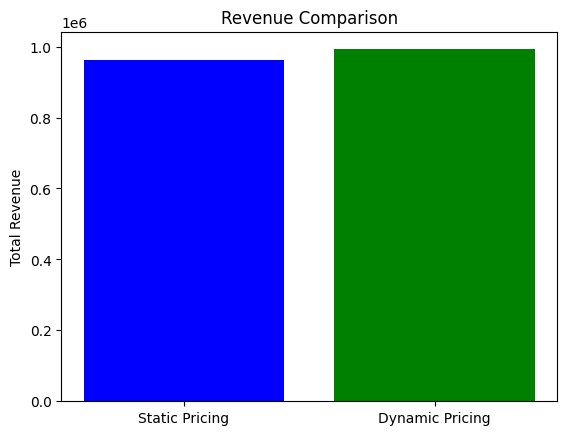

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["Static Pricing","Dynamic Pricing"],
        [original_total_revenue, dynamic_total_revenue],
        color=["blue","green"])

plt.title("Revenue Comparison")
plt.ylabel("Total Revenue")
plt.show()